
--- Step 0: Loading Single Day Data ---
Successfully loaded 84125 points.

--- Step 1: Denoising (Binning + Gaussian Smooth) ---
Binned/Interpolated/Smoothed: 720 points.

--- Step 2: Finding Initial Peaks (Prominence > 200.0) ---
Found 25 initial peaks.

--- Step 3: Finding Flare Durations (Slope Algorithm) ---
Found 25 durations.

--- Step 4: Merging Flares ---
Merged to 20 durations.

--- Step 5: Final Background ---
BG estimated.

Applied noise clip threshold: 44.71

--- Step 7: Starting EFP Modeling ---
--- Found 24 peaks for final fitting ---
EFP modeling complete. Successfully fitted 21 flares.


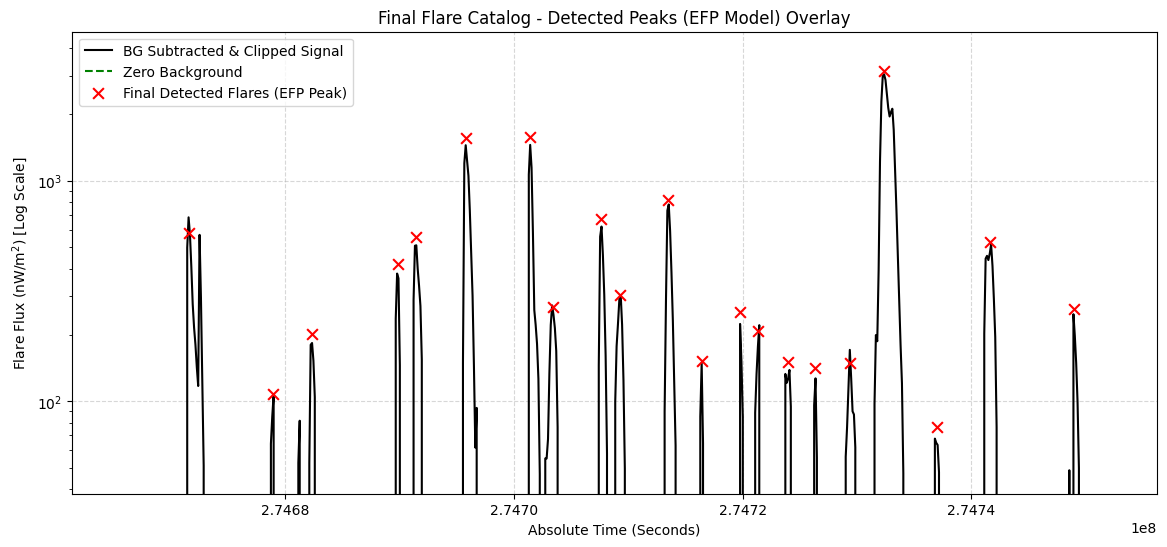

        PeakTime  PeakFlux_nW/m2     StartFWTM       EndFWTM   FittedSNR  \
0   2.746716e+08      578.966618  2.746714e+08  2.746745e+08   48.976623   
1   2.746789e+08      107.847595  2.746787e+08  2.746790e+08    3.486785   
2   2.746823e+08      202.479025  2.746821e+08  2.746828e+08    9.844640   
3   2.746898e+08      419.510930  2.746896e+08  2.746899e+08   16.262234   
4   2.746914e+08      555.781263  2.746912e+08  2.746932e+08   32.205858   
5   2.746958e+08     1556.330639  2.746956e+08  2.746975e+08   93.096254   
6   2.747014e+08     1580.033818  2.747013e+08  2.747026e+08   65.109277   
7   2.747034e+08      268.512238  2.747030e+08  2.747036e+08   20.547903   
8   2.747076e+08      668.363381  2.747075e+08  2.747087e+08   32.091049   
9   2.747093e+08      301.903061  2.747089e+08  2.747094e+08   20.159647   
10  2.747135e+08      819.037492  2.747133e+08  2.747146e+08   43.921997   
11  2.747164e+08      152.598324  2.747163e+08  2.747165e+08    4.040115   
12  2.747198

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import binned_statistic
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit 
from scipy.special import erfc      
import matplotlib.pyplot as plt
from astropy.table import Table
import os
from datetime import datetime, timedelta

# --- 1. Define All Algorithm Parameters ---
BIN_SIZE_SECONDS = 120.0
SIGMA_G = 2.0
PEAK_PROMINENCE = 200.0  # Initial peak finding
SLOPE_THRESHOLD = 0.5
MERGE_THRESHOLD_SECONDS = 600.0
N_SIGMA_CLIP = 0.3       # Final noise clipping level

# --- EFP Fitting Parameters ---
FINAL_PEAK_PROMINENCE = 50.0 
FINAL_PEAK_HEIGHT = 1.0      
COUNT_TO_NW_M2_FACTOR = 1.0 
Y_LABEL_FLUX = r"Flux (nW/m$^2$)"

# =================================================================
# --- EFP MODEL FUNCTIONS (Stable versions) ---
# =================================================================
MAX_EXP_ARG_CLIP = 50.0
def elementary_flare_profile(t, A, mu, sigma, tau):
    """Numerically stable Elementary Flare Profile (EFP) core function (4-param)."""
    sigma = np.abs(sigma); tau = np.abs(tau)
    if sigma < 1e-4: sigma = 1e-4
    if tau < 1e-4: tau = 1e-4
    if tau < 1e-3:
        A_prime = A * sigma * np.sqrt(np.pi / 2.0); exp_arg_gauss = -0.5 * ((t - mu) / sigma)**2; exp_arg_gauss = np.clip(exp_arg_gauss, a_min=-np.inf, a_max=MAX_EXP_ARG_CLIP)
        return A_prime * np.exp(exp_arg_gauss)
    A_prime = A * (sigma / tau) * np.sqrt(np.pi / 2.0)
    exp_arg = 0.5 * (sigma / tau)**2 - (t - mu) / tau; exp_arg = np.clip(exp_arg, a_min=-np.inf, a_max=MAX_EXP_ARG_CLIP)
    exp_part = np.exp(exp_arg); erfc_arg = (1.0 / np.sqrt(2.0)) * (sigma / tau - (t - mu) / sigma)
    erfc_part = erfc(erfc_arg); result = A_prime * exp_part * erfc_part
    return np.nan_to_num(result)

def get_fitted_parameters(t, rate, p_opt, background_segment):
    """Calculates Peak Time, FWTM, Peak Flux, CORRECT SNR, and R² reliability."""
    A, mu, sigma, tau = p_opt[0:4]
    
    # Basic sanity check
    if any(np.isnan(p_opt)) or sigma <= 0 or tau <= 0:
        return None

    # --- Fitted signal & background ---
    S_fitted = elementary_flare_profile(t, A, mu, sigma, tau)
    B_background = np.maximum(0, background_segment)
    S_fitted_nonneg = np.maximum(0, S_fitted)
    
    # --- Compute SNR ---
    denominator_term = S_fitted_nonneg + 2 * B_background
    denominator_term[denominator_term < 1e-9] = 1e-9
    snr_terms = S_fitted_nonneg / np.sqrt(denominator_term)
    fitted_snr = np.sum(snr_terms)

    # --- Peak info using dense sampling ---
    t_dense = np.linspace(t.min(), t.max(), 500)
    fitted_curve_dense = elementary_flare_profile(t_dense, A, mu, sigma, tau)
    if np.all(np.isnan(fitted_curve_dense)) or len(fitted_curve_dense) == 0:
        return None

    peak_index = np.nanargmax(fitted_curve_dense)
    peak_time = t_dense[peak_index]
    peak_flux_counts = fitted_curve_dense[peak_index]
    peak_flux_nw = peak_flux_counts * COUNT_TO_NW_M2_FACTOR

    # --- FWTM (full width at tenth maximum) ---
    start_time_fwtm = peak_time - 1.5 * np.abs(sigma)
    end_time_fwtm = peak_time + 5.0 * np.abs(tau)

    # --- Compute R² reliability ---
    # Use the same time segment for R² computation
    ss_res = np.sum((rate - S_fitted)**2)
    ss_tot = np.sum((rate - np.mean(rate))**2)
    r_squared = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else 0.0

    return {
        'PeakTime': peak_time,
        'PeakFlux_nW/m2': peak_flux_nw,
        'StartFWTM': start_time_fwtm,
        'EndFWTM': end_time_fwtm,
        'FittedSNR': fitted_snr,
        'DecayTau': np.abs(tau),
        'RiseSigma': np.abs(sigma),
        'Fitted_A': A,
        'R_squared': r_squared   # Added reliability factor
    }


def model_and_characterize_flares(time_array, subtracted_signal_array, final_background_array,
                                prominence=50.0, height=1.0, show_plots=False):
    """Fits EFP model and calculates parameters including the correct SNR."""
    print(f"\n--- Step 7: Starting EFP Modeling ---")
    peak_indices, _ = find_peaks(subtracted_signal_array, prominence=prominence, height=height)
    print(f"--- Found {len(peak_indices)} peaks for final fitting ---")
    if len(peak_indices) == 0: return pd.DataFrame()

    final_catalog_data = []
    processed_indices = np.zeros_like(subtracted_signal_array, dtype=bool)

    for peak_idx in peak_indices:
        if processed_indices[peak_idx]: continue
        start_idx = peak_idx; end_idx = peak_idx
        for i in range(peak_idx - 1, -1, -1):
            if subtracted_signal_array[i] <= 0 or i == 0: start_idx = i; break
        for i in range(peak_idx + 1, len(subtracted_signal_array)):
            if subtracted_signal_array[i] <= 0 or i == len(subtracted_signal_array) - 1: end_idx = i; break

        if start_idx >= end_idx:
            continue
        segment_mask = np.arange(start_idx, end_idx + 1); segment_mask = segment_mask[(segment_mask >= 0) & (segment_mask < len(time_array))]
        if len(segment_mask) < 5:
            continue

        t_flare = time_array[segment_mask]; r_flare = subtracted_signal_array[segment_mask]
        if max(segment_mask) < len(final_background_array): background_flare = final_background_array[segment_mask]
        else: continue

        if len(t_flare) < 5: continue
        r_peak_time_guess = t_flare[np.argmax(r_flare)]
        r_peak_flux_guess = r_flare.max()
        if r_peak_flux_guess <= 0: continue

        p0 = [r_peak_flux_guess, r_peak_time_guess, 50.0, 200.0]; lower_bounds = [0.0, t_flare.min(), 1.0, 5.0]; upper_bounds = [r_peak_flux_guess * 2.5, t_flare.max(), 1000.0, 2000.0]

        try:
            p_opt, p_cov = curve_fit(elementary_flare_profile, t_flare, r_flare, p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=5000)
            flare_props = get_fitted_parameters(t_flare, r_flare, p_opt, background_flare)
            if flare_props and not np.isnan(flare_props['PeakTime']):
                final_catalog_data.append(flare_props); processed_indices[segment_mask] = True
        except Exception as e: pass
    print(f"EFP modeling complete. Successfully fitted {len(final_catalog_data)} flares.")
    return pd.DataFrame(final_catalog_data)

# =================================================================
# --- CORE ALGORITHM FUNCTIONS ---
# =================================================================
def load_single_day_data(current_file_path):
    print(f"\n--- Step 0: Loading Single Day Data ---")
    if not os.path.exists(current_file_path):
        print(f"FATAL: File not found at {current_file_path}")
        return None, None
    try:
        lc_data = Table.read(current_file_path)
        df = pd.DataFrame({'TIME': lc_data['TIME'].value.astype(float), 'RATE': lc_data['RATE'].value.astype(float)})
        boundaries = (df['TIME'].min(), df['TIME'].max())
        print(f"Successfully loaded {len(df)} points.")
        return df, boundaries
    except Exception as e:
        print(f"Error loading {os.path.basename(current_file_path)}: {e}")
        return None, None

def denoise_data(dataframe, time_col, rate_col, bin_size_sec, sigma_g):
    print(f"\n--- Step 1: Denoising (Binning + Gaussian Smooth) ---")
    try: original_time = dataframe[time_col].values; original_rate = dataframe[rate_col].values
    except KeyError as e: print(f"FATAL: Column missing: {e}"); return None, None, None

    min_time, max_time = original_time.min(), original_time.max(); edges = np.arange(min_time, max_time + bin_size_sec, bin_size_sec)
    r_bin, _, _ = binned_statistic(original_time, original_rate, 'mean', edges)
    t_bin = (edges[:-1] + edges[1:]) / 2
    temp_df = pd.DataFrame({'TIME': t_bin, 'RATE': r_bin}).interpolate('linear', limit_direction='both'); r_bin_i, t_bin_i = temp_df['RATE'].values, temp_df['TIME'].values
    
    smoothed = gaussian_filter1d(r_bin_i, sigma_g, mode='nearest')
    print(f"Binned/Interpolated/Smoothed: {len(t_bin_i)} points.")
    return t_bin_i, r_bin_i, smoothed

def find_initial_peaks(binned_signal, prominence):
    print(f"\n--- Step 2: Finding Initial Peaks (Prominence > {prominence}) ---"); indices, _ = find_peaks(binned_signal, prominence=prominence); print(f"Found {len(indices)} initial peaks."); return indices

def find_flare_durations(time, smoothed_curve, peak_indices, slope_thresh):
    """
    Step 3: Implements the 'Slope Algorithm' to find flare start/end times.
    """
    print(f"\n--- Step 3: Finding Flare Durations (Slope Algorithm) ---")
    flare_intervals = []
    time, smoothed = np.asarray(time), np.asarray(smoothed_curve); n_points = len(time)

    for idx in peak_indices:
        if idx < 4 or idx >= n_points - 4: continue
        
        start_idx = idx
        end_idx = idx

        for i in range(idx - 4, 0, -1): 
            start_slope_idx = i - 3; end_slope_idx = i + 1;
            if start_slope_idx < 0: break 
            x, y = time[start_slope_idx:end_slope_idx], smoothed[start_slope_idx:end_slope_idx]
            if len(x)!=4 or np.isnan(x).any() or np.isnan(y).any(): continue
            try: slope = np.polyfit(x, y, 1)[0];
            except: continue
            if np.abs(slope) < slope_thresh: start_idx = i; break

        for i in range(idx, n_points - 4):
            start_slope_idx = i; end_slope_idx = i + 4;
            if end_slope_idx > n_points: break 
            x, y = time[start_slope_idx:end_slope_idx], smoothed[start_slope_idx:end_slope_idx]
            if len(x)!=4 or np.isnan(x).any() or np.isnan(y).any(): continue
            try: slope = np.polyfit(x, y, 1)[0];
            except: continue
            if np.abs(slope) < slope_thresh: end_idx = i + 4; break
        
        is_valid_walk = (0 <= start_idx < n_points and 0 <= end_idx < n_points and start_idx < end_idx)
                         
        if is_valid_walk:
             flare_intervals.append([time[start_idx], time[end_idx]])
        else: 
             fallback_start_idx = max(0, idx - 2) 
             fallback_end_idx = min(n_points - 1, idx + 2)
             
             if fallback_start_idx < fallback_end_idx:
                 flare_intervals.append([time[fallback_start_idx], time[fallback_end_idx]])

    print(f"Found {len(flare_intervals)} durations.");
    return flare_intervals

def merge_close_flares(fi, merge_t):
    print(f"\n--- Step 4: Merging Flares ---")
    if not fi: return []
    ints = sorted(fi, key=lambda x: x[0])
    merged = [ints[0]]
    for cur_s, cur_e in ints[1:]:
        last_s, last_e = merged[-1]
        if cur_s - last_e < merge_t: merged[-1][1] = max(last_e, cur_e)
        else: merged.append([cur_s, cur_e])
    print(f"Merged to {len(merged)} durations."); return merged

def estimate_final_background(t, sig, mi):
    print(f"\n--- Step 5: Final Background ---"); mask = np.ones_like(t, dtype=bool)
    for s, e in mi: mask[(t >= s) & (t <= e)] = False
    qt, qr = t[mask], sig[mask];
    if len(qt) < 2: print("Warn: <2 quiet points."); return gaussian_filter1d(np.asarray(sig), SIGMA_G, mode='nearest')
    try: interp = interp1d(qt, qr, 'linear', fill_value='extrapolate'); bg = interp(t); print("BG estimated."); return bg
    except ValueError as e: print(f"Interp Error: {e}. Using BG1."); return gaussian_filter1d(np.asarray(sig), SIGMA_G, mode='nearest')

# =================================================================
# --- FINAL PLOTTING FUNCTION ---
# =================================================================
def plot_final_fitted_catalog(binned_time, final_clipped_signal, final_flare_catalog):
    
    plt.figure(figsize=(14, 6))
    
    # Plot 1: The Final Clipped Signal (Black Curve)
    plt.plot(binned_time, final_clipped_signal, color='black', label='BG Subtracted & Clipped Signal')
    
    # Plot 2: Zero Background Line (Green Dashed)
    plt.axhline(0, color='green', linestyle='--', label='Zero Background')

    # Plot 3: Detected Flare Peaks from EFP Fit (Red 'x')
    plt.scatter(final_flare_catalog['PeakTime'], final_flare_catalog['PeakFlux_nW/m2'], 
                color='red', marker='x', s=60, zorder=10, label='Final Detected Flares (EFP Peak)')
    
    # --- Formatting ---
    plt.title("Final Flare Catalog - Detected Peaks (EFP Model) Overlay")
    plt.xlabel("Absolute Time (Seconds)")
    plt.ylabel(r"Flare Flux (nW/m$^2$) [Log Scale]")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # Apply Log Scale and set limits
    plt.yscale('log')
    min_plot_val = final_flare_catalog['PeakFlux_nW/m2'].min() * 0.5 if not final_flare_catalog.empty else 1.0
    max_plot_val = final_flare_catalog['PeakFlux_nW/m2'].max() * 1.5 if not final_flare_catalog.empty else 10.0
    plt.ylim(bottom=max(1.0, min_plot_val), top=max_plot_val)
    plt.show()

# =================================================================
# --- MAIN EXECUTION PIPELINE (WITHOUT STITCHING) ---
# =================================================================
# # def full_analysis_no_stitching(target_lc_file):
    
#     # Step 0: Load Data (No Stitching)
#     df_target, boundaries = load_single_day_data(target_lc_file)
#     if df_target is None: return

#     # Step 1: Denoise (Binning + Gaussian Smooth)
#     binned_time, binned_signal, smoothed_signal = denoise_data(
#         df_target, 'TIME', 'RATE', BIN_SIZE_SECONDS, SIGMA_G
#     )
#     # plt.plot()
#     if binned_time is None: return

#     # Step 2: Find Peaks
#     peak_indices = find_initial_peaks(binned_signal, PEAK_PROMINENCE)
    
#     # Step 3 & 4: Find Durations and Merge
#     flare_intervals = find_flare_durations(binned_time, smoothed_signal, peak_indices, SLOPE_THRESHOLD)
#     merged_flare_intervals = merge_close_flares(flare_intervals, MERGE_THRESHOLD_SECONDS)
    
#     # Step 5: Estimate Final Background (BG 2)
#     final_background = estimate_final_background(binned_time, binned_signal, merged_flare_intervals)

#     # Step 6: Subtract Final Background and Final Clip
#     subtracted_signal = binned_signal - final_background
#     subtracted_signal = np.maximum(0, subtracted_signal)

#     non_zero_signal = subtracted_signal[subtracted_signal > 1e-6]
#     if len(non_zero_signal) > 10:
#         mad = np.median(np.abs(non_zero_signal - np.median(non_zero_signal)))
#         sigma_est = mad * 1.4826
#         noise_threshold = N_SIGMA_CLIP * sigma_est
#         final_clipped_signal = np.where(subtracted_signal >= noise_threshold, subtracted_signal, 0)
#         print(f"\nApplied noise clip threshold: {noise_threshold:.2f}")
#     else:
#         final_clipped_signal = subtracted_signal
#         print("\nSkipped noise clip.")

#     # --- Step 7: Model and Characterize Flares ---
#     final_flare_catalog = model_and_characterize_flares(
#         time_array=binned_time,
#         subtracted_signal_array=final_clipped_signal,
#         final_background_array=final_background,
#         prominence=FINAL_PEAK_PROMINENCE,
#         height=FINAL_PEAK_HEIGHT
#     )

#     # --- FINAL OUTPUT/PLOTTING ---
#     if not final_flare_catalog.empty:
#         print("\n" + "="*50)
#         print("--- FINAL FLARE CATALOG (EFP FITTED) ---")
#         print("="*50)
#         display_cols = ['PeakTime', 'PeakFlux_nW/m2', 'StartFWTM', 'EndFWTM', 'FittedSNR', 'DecayTau', 'RiseSigma']
#         print(final_flare_catalog[display_cols].round(2))

#         # --- Final Plotting (Based on EFP Catalog) ---
#         plot_final_fitted_catalog(binned_time, final_clipped_signal, final_flare_catalog)

#     else:
#         print("\nNo flares were successfully modeled.")
def full_analysis_no_stitching(target_lc_file):

    # Step 0: Load Data
    df_target, boundaries = load_single_day_data(target_lc_file)
    if df_target is None: return None, None, None

    # Step 1: Denoise
    binned_time, binned_signal, smoothed_signal = denoise_data(
        df_target, 'TIME', 'RATE', BIN_SIZE_SECONDS, SIGMA_G
    )
    if binned_time is None: return None, None, None

    # Step 2: Find Peaks
    peak_indices = find_initial_peaks(binned_signal, PEAK_PROMINENCE)

    # Step 3 & 4: Find Durations and Merge
    flare_intervals = find_flare_durations(binned_time, smoothed_signal, peak_indices, SLOPE_THRESHOLD)
    merged_flare_intervals = merge_close_flares(flare_intervals, MERGE_THRESHOLD_SECONDS)

    # Step 5: Estimate Final Background
    final_background = estimate_final_background(binned_time, binned_signal, merged_flare_intervals)

    # Step 6: Subtract Final Background and Clip
    subtracted_signal = binned_signal - final_background
    subtracted_signal = np.maximum(0, subtracted_signal)

    non_zero_signal = subtracted_signal[subtracted_signal > 1e-6]
    if len(non_zero_signal) > 10:
        mad = np.median(np.abs(non_zero_signal - np.median(non_zero_signal)))
        sigma_est = mad * 1.4826
        noise_threshold = N_SIGMA_CLIP * sigma_est
        final_clipped_signal = np.where(subtracted_signal >= noise_threshold, subtracted_signal, 0)
        print(f"\nApplied noise clip threshold: {noise_threshold:.2f}")
    else:
        final_clipped_signal = subtracted_signal
        print("\nSkipped noise clip.")

    # Step 7: Model and Characterize Flares
    final_flare_catalog = model_and_characterize_flares(
        time_array=binned_time,
        subtracted_signal_array=final_clipped_signal,
        final_background_array=final_background,
        prominence=FINAL_PEAK_PROMINENCE,
        height=FINAL_PEAK_HEIGHT
    )

    # Final Plot
    if not final_flare_catalog.empty:
        plot_final_fitted_catalog(binned_time, final_clipped_signal, final_flare_catalog)

    return binned_time, final_clipped_signal, final_flare_catalog

# --- Execution ---
target_lc_file_example = r'ALL_DATA/ch2_xsm_20250915_v1_level2.lc'
binned_time, final_clipped_signal, final_flare_catalog = full_analysis_no_stitching(target_lc_file_example)
print(final_flare_catalog)

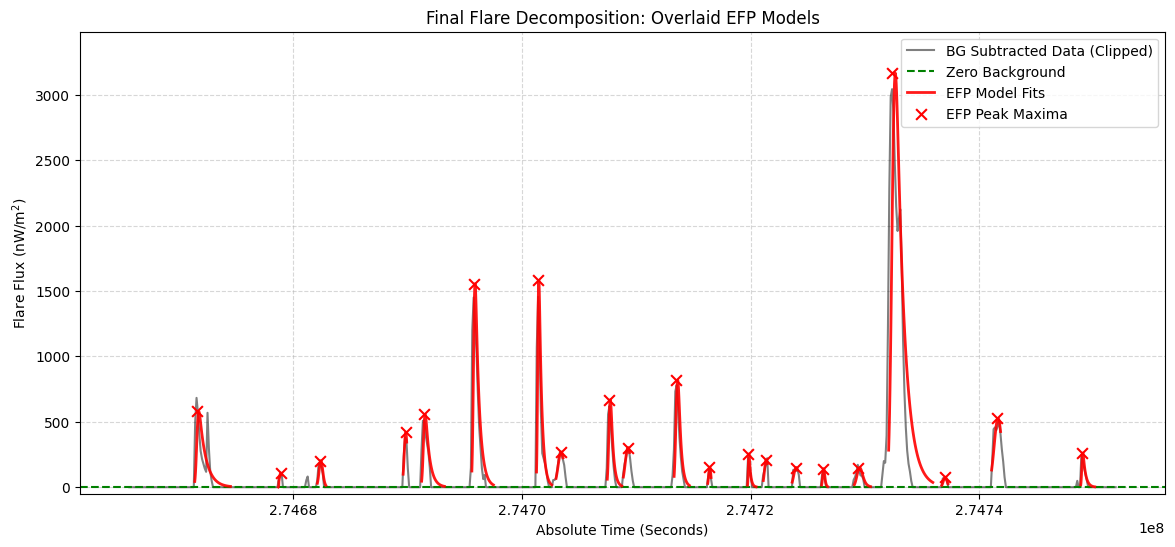

        PeakTime  PeakFlux_nW/m2     StartFWTM       EndFWTM   FittedSNR  \
0   2.746716e+08      578.966618  2.746714e+08  2.746745e+08   48.976623   
1   2.746789e+08      107.847595  2.746787e+08  2.746790e+08    3.486785   
2   2.746823e+08      202.479025  2.746821e+08  2.746828e+08    9.844640   
3   2.746898e+08      419.510930  2.746896e+08  2.746899e+08   16.262234   
4   2.746914e+08      555.781263  2.746912e+08  2.746932e+08   32.205858   
5   2.746958e+08     1556.330639  2.746956e+08  2.746975e+08   93.096254   
6   2.747014e+08     1580.033818  2.747013e+08  2.747026e+08   65.109277   
7   2.747034e+08      268.512238  2.747030e+08  2.747036e+08   20.547903   
8   2.747076e+08      668.363381  2.747075e+08  2.747087e+08   32.091049   
9   2.747093e+08      301.903061  2.747089e+08  2.747094e+08   20.159647   
10  2.747135e+08      819.037492  2.747133e+08  2.747146e+08   43.921997   
11  2.747164e+08      152.598324  2.747163e+08  2.747165e+08    4.040115   
12  2.747198

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import binned_statistic
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit 
from scipy.special import erfc      
import matplotlib.pyplot as plt
from astropy.table import Table
import os
from datetime import datetime, timedelta

# --- 1. Define All Algorithm Parameters (Required for helper functions) ---
BIN_SIZE_SECONDS = 120.0
SIGMA_G = 2.0
PEAK_PROMINENCE = 200.0  
SLOPE_THRESHOLD = 0.5
MERGE_THRESHOLD_SECONDS = 600.0
N_SIGMA_CLIP = 0.3       
FINAL_PEAK_PROMINENCE = 50.0 
FINAL_PEAK_HEIGHT = 1.0      
COUNT_TO_NW_M2_FACTOR = 1.0 
Y_LABEL_FLUX = r"Flux (nW/m$^2$)"
MAX_EXP_ARG_CLIP = 50.0

# =================================================================
# --- EFP MODEL FUNCTIONS (Required for plotting the fitted curves) ---
# =================================================================
def elementary_flare_profile(t, A, mu, sigma, tau):
    """Numerically stable Elementary Flare Profile (EFP) core function."""
    sigma = np.abs(sigma); tau = np.abs(tau)
    if sigma < 1e-4: sigma = 1e-4
    if tau < 1e-4: tau = 1e-4
    if tau < 1e-3:
        A_prime = A * sigma * np.sqrt(np.pi / 2.0); exp_arg_gauss = -0.5 * ((t - mu) / sigma)**2; exp_arg_gauss = np.clip(exp_arg_gauss, a_min=-np.inf, a_max=MAX_EXP_ARG_CLIP); return A_prime * np.exp(exp_arg_gauss)
    A_prime = A * (sigma / tau) * np.sqrt(np.pi / 2.0); exp_arg = 0.5 * (sigma / tau)**2 - (t - mu) / tau; exp_arg = np.clip(exp_arg, a_min=-np.inf, a_max=MAX_EXP_ARG_CLIP); exp_part = np.exp(exp_arg); erfc_arg = (1.0 / np.sqrt(2.0)) * (sigma / tau - (t - mu) / sigma); erfc_part = erfc(erfc_arg); result = A_prime * exp_part * erfc_part
    return np.nan_to_num(result)

# --- FINAL PLOTTING FUNCTION (NEW) ---
def plot_all_efp_models(binned_time, final_clipped_signal, final_flare_catalog):
    """Plots the final background-subtracted signal with EFP fits overlaid."""
    
    plt.figure(figsize=(14, 6))
    
    # Plot 1: The Final Clipped Data (Black Curve)
    plt.plot(binned_time, final_clipped_signal, color='black', label='BG Subtracted Data (Clipped)', alpha=0.5)
    
    # Plot 2: Zero Background Line (Green Dashed)
    plt.axhline(0, color='green', linestyle='--', label='Zero Background')

    # --- Loop through catalog and plot each EFP fit ---
    first_fit = True
    for index, row in final_flare_catalog.iterrows():
        # Get parameters for this flare
        A, mu, sigma, tau = row['Fitted_A'], row['PeakTime'], row['RiseSigma'], row['DecayTau']
        
        # Define the time range for the fitted curve (using FWTM bounds from catalog)
        plot_start = row['StartFWTM'] - 10 
        plot_end = row['EndFWTM'] + 10     
        
        t_fit_dense = np.linspace(plot_start, plot_end, 100)
        
        # Calculate the EFP curve using the derived parameters
        r_fit = elementary_flare_profile(t_fit_dense, A, mu, sigma, tau)
        
        # Plot the smooth EFP curve (use one label for all, rest are None)
        label = 'EFP Model Fits' if first_fit else None
        plt.plot(t_fit_dense, r_fit, color='red', linewidth=2.0, alpha=0.9, label=label)
        
        first_fit = False # Ensure label is only used once

    # Plot 3: Detected Peaks (Red 'x') - Marks the calculated peak of the fit
    plt.scatter(final_flare_catalog['PeakTime'], final_flare_catalog['PeakFlux_nW/m2'], 
                color='red', marker='x', s=60, zorder=10, label='EFP Peak Maxima')
    
    # --- Formatting ---
    plt.title("Final Flare Decomposition: Overlaid EFP Models")
    plt.xlabel("Absolute Time (Seconds)")
    plt.ylabel(r"Flare Flux (nW/m$^2$)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # Set Y limits (Linear Scale)
    max_flux = final_flare_catalog['PeakFlux_nW/m2'].max()
    plt.ylim(bottom=-50, top=max_flux * 1.1 if max_flux > 0 else 1000)
    plt.show()

# =================================================================
# --- CORE EXECUTION (Assuming full pipeline ran successfully) ---
# =================================================================

# The rest of the pipeline functions (load_single_day_data, denoise_data, etc.) 
# are assumed to have run, making 'binned_time', 'final_clipped_signal', 
# and 'final_flare_catalog' available.

# # Example Call:
plot_all_efp_models(binned_time, final_clipped_signal, final_flare_catalog)
print(final_flare_catalog)
# # Specify the file you want to process (16th September, for example)
# target_lc_file_example = r'ALL_DATA/ch2_xsm_20250916_v1_level2.lc'

# # Run the full analysis pipeline
# full_analysis_no_stitching(target_lc_file_example)

# # At this point, the pipeline has generated:
# # binned_time, final_clipped_signal, final_flare_catalog
# # Now you can call your plotting function

# # Optional: view the catalog
# print(final_flare_catalog)


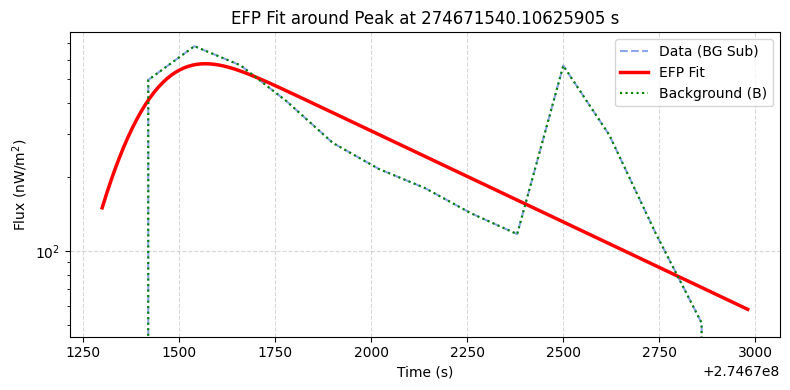

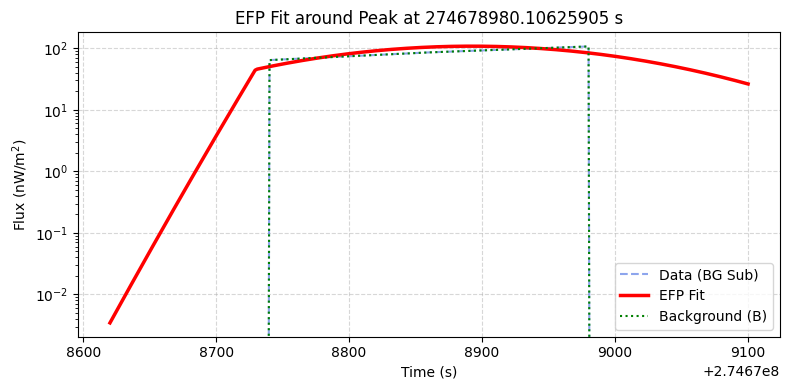

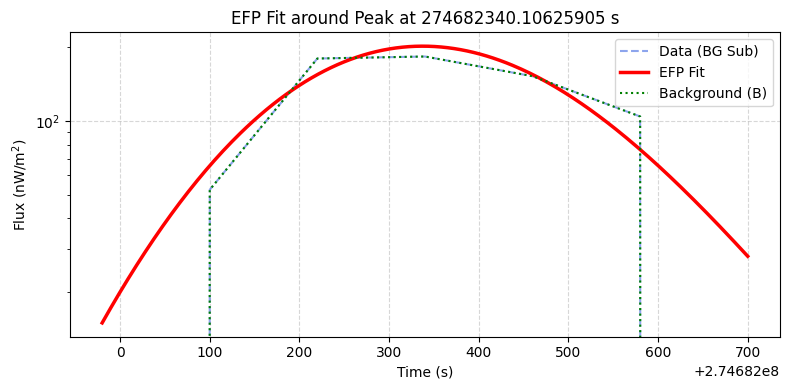

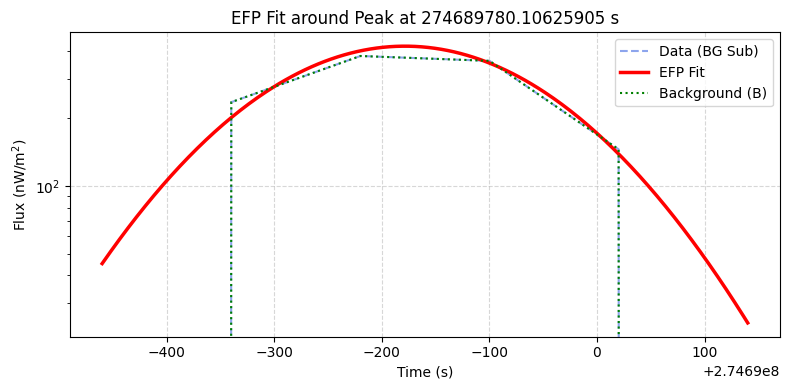

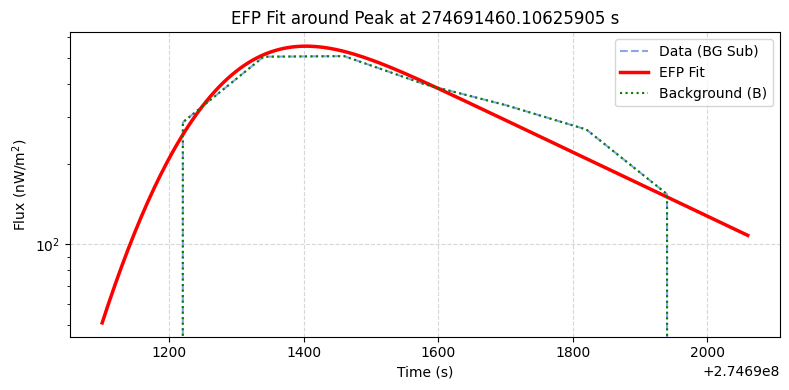

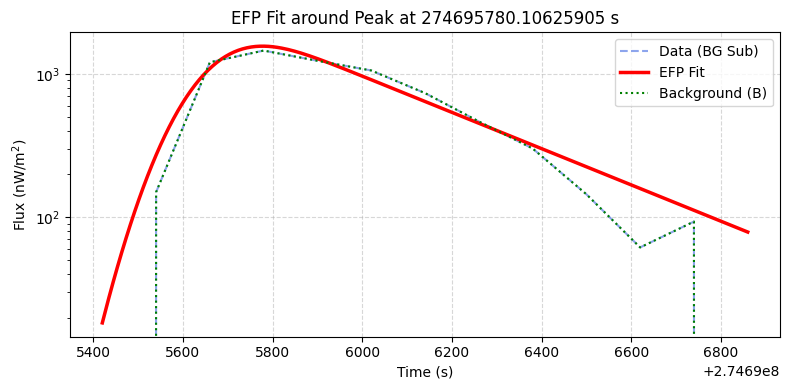

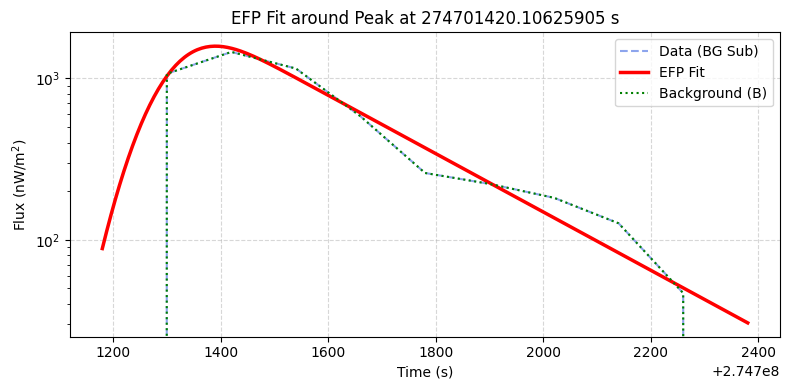

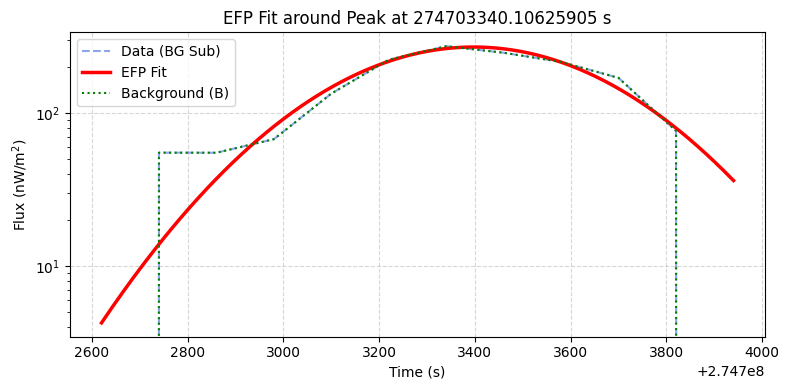

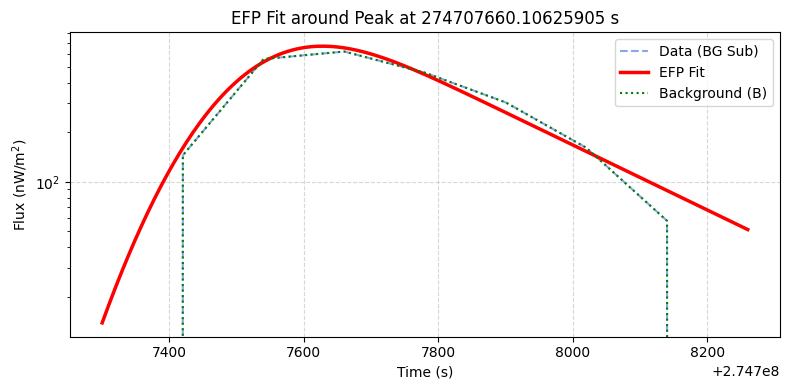

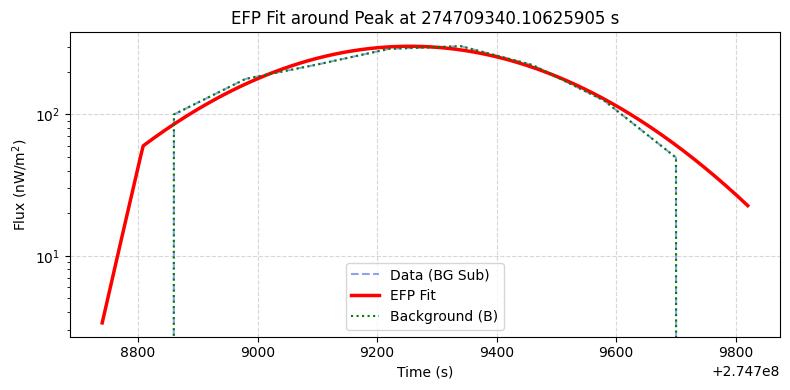

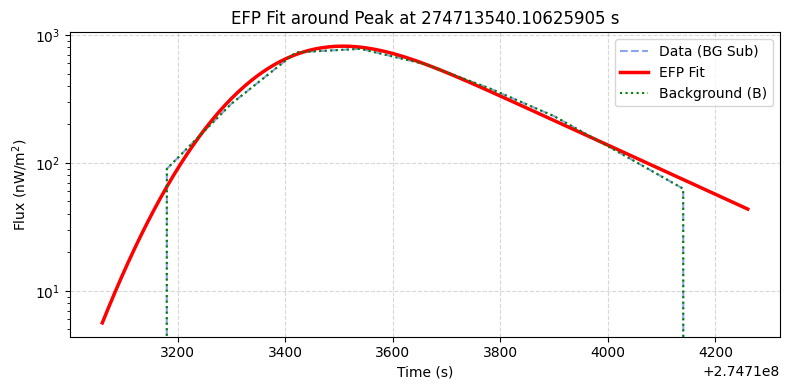

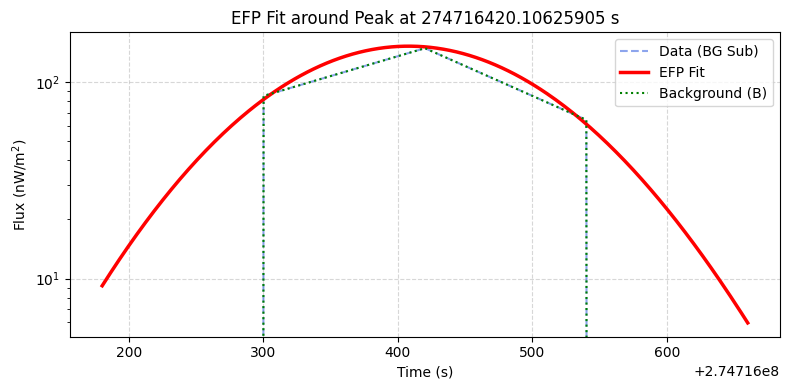

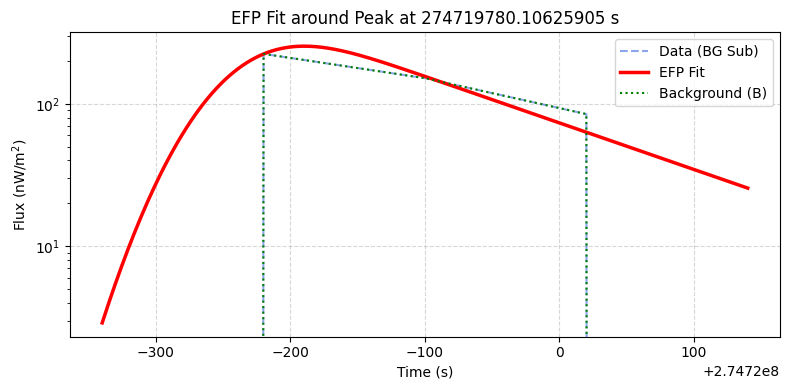

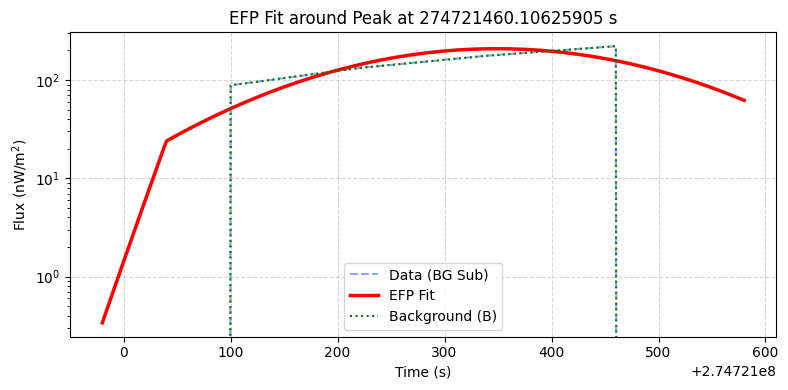

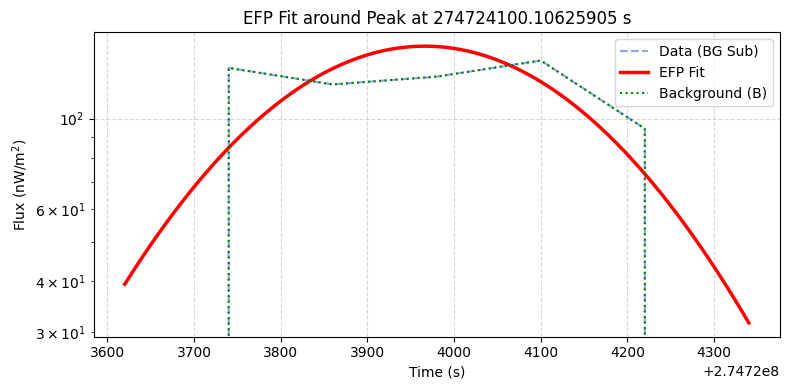

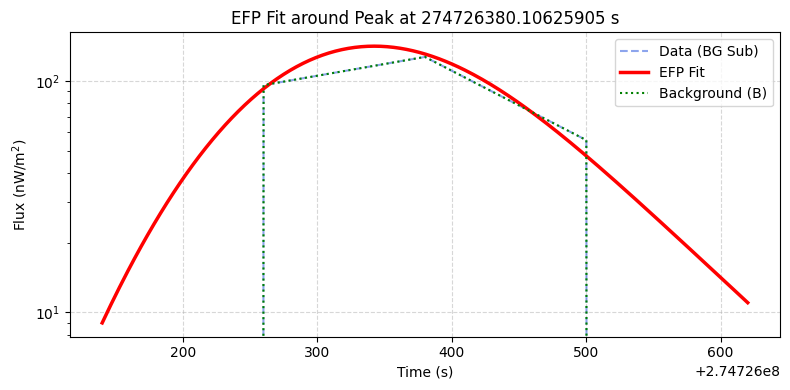

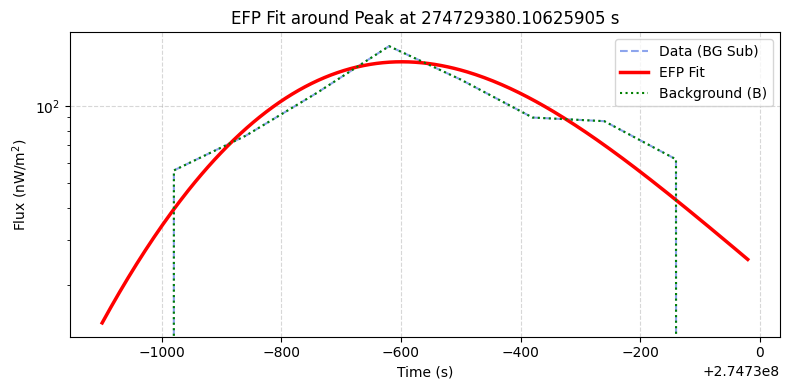

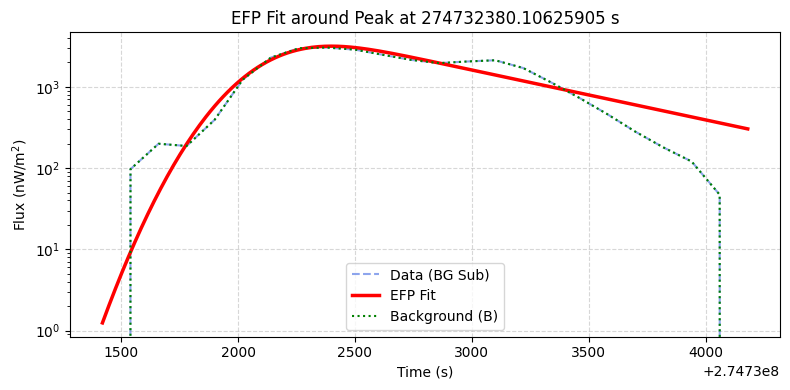

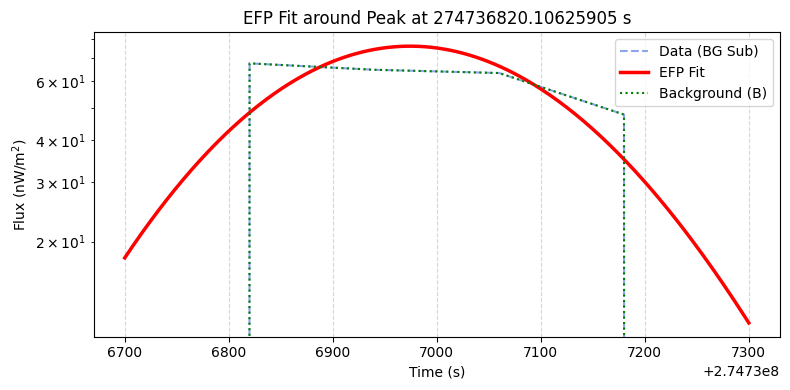

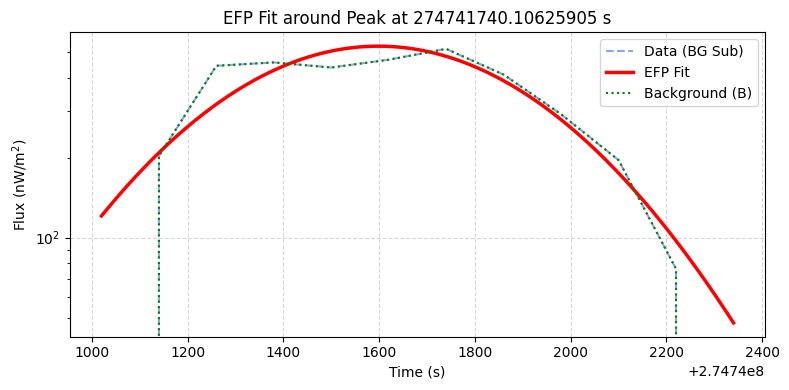

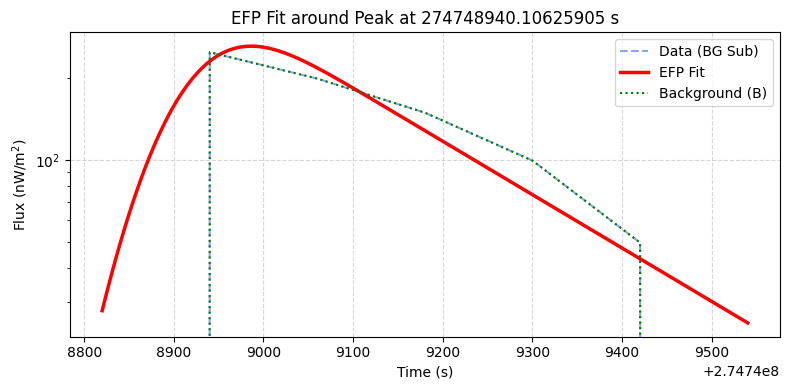

In [7]:
def plot_efp_on_selected_peaks(time_array, signal_array, peak_indices, background_array):
    for peak_idx in peak_indices:
        # --- isolate flare region ---
        start_idx = peak_idx
        end_idx = peak_idx
        for i in range(peak_idx - 1, -1, -1):
            if signal_array[i] <= 0 or i == 0:
                start_idx = i
                break
        for i in range(peak_idx + 1, len(signal_array)):
            if signal_array[i] <= 0 or i == len(signal_array) - 1:
                end_idx = i
                break
        
        if end_idx <= start_idx:
            continue
        
        t_flare = time_array[start_idx:end_idx+1]
        r_flare = signal_array[start_idx:end_idx+1]
        background_flare = background_array[start_idx:end_idx+1]
        
        # --- fit EFP model ---
        r_peak_flux_guess = r_flare.max()
        r_peak_time_guess = t_flare[np.argmax(r_flare)]
        p0 = [r_peak_flux_guess, r_peak_time_guess, 50.0, 200.0]
        bounds = ([0, t_flare.min(), 1.0, 5.0],
                  [r_peak_flux_guess*2.5, t_flare.max(), 1000.0, 2000.0])
        
        try:
            p_opt, _ = curve_fit(elementary_flare_profile, t_flare, r_flare, p0=p0, bounds=bounds, maxfev=5000)
            t_fit = np.linspace(t_flare.min(), t_flare.max(), 300)
            r_fit = elementary_flare_profile(t_fit, *p_opt)
            
            # --- plot beautifully ---
            plt.figure(figsize=(8, 4))
            plt.plot(t_flare, r_flare, '--', color='royalblue', alpha=0.6, label='Data (BG Sub)')
            plt.plot(t_fit, r_fit, color='red', lw=2.5, label='EFP Fit')
            plt.plot(t_flare, background_flare, color='green', ls=':', label='Background (B)')
            plt.xlabel("Time (s)")
            plt.ylabel(r"Flux (nW/m$^2$)")
            plt.yscale("log")
            plt.legend()
             # --- title with peak time ---
            plt.title(f"EFP Fit around Peak at {r_peak_time_guess} s")
            
            plt.grid(True, ls="--", alpha=0.5)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Fit failed near {r_peak_time_guess:.1f}s: {e}")


# Convert PeakTime (float seconds) → nearest index in
#  binned_time
my_peak_indices = [
    np.argmin(np.abs(binned_time - t))
    for t in final_flare_catalog['PeakTime']
]

# Now call the plotting function with indices
plot_efp_on_selected_peaks(
    binned_time,
    final_clipped_signal,
    my_peak_indices,
    final_clipped_signal
)
# final_flare_catalog.shape

In [10]:
import pandas as pd
import numpy as np

# --- Thresholds ---
SNR_THRESHOLD = 8.0 
R_SQUARED_THRESHOLD = 0.5 
BG_LEVEL_DECAY_TAU_THRESHOLD = 1.0e7 

try:
    df_fitted = final_flare_catalog.copy()
    # Drop old index column if exists
    if 'Index' in df_fitted.columns:
        df_fitted = df_fitted.drop(columns=['Index'])
    print("DataFrame parsed successfully!")
except Exception as e:
    print(f"Error parsing data: {e}")
    df_fitted = pd.DataFrame()  # Empty DF to avoid later errors

if not df_fitted.empty and 'FittedSNR' in df_fitted.columns: 
    print("\n--- Applying Catalog Filters ---")
    initial_count = len(df_fitted)
    filtered_catalog = df_fitted.copy()

    # --- Filter 1: Reliability Filter ---
    snr_mask = filtered_catalog['FittedSNR'] >= SNR_THRESHOLD
    r2_mask = filtered_catalog['R_squared'] >= R_SQUARED_THRESHOLD
    reliable_mask = snr_mask & r2_mask
    print(f"1. Reliability Filter (SNR >= {SNR_THRESHOLD} & R² >= {R_SQUARED_THRESHOLD}):")
    print(f"   Keeping {reliable_mask.sum()} / {len(filtered_catalog)} flares.")
    print(f"   Rejected due to SNR < {SNR_THRESHOLD}: {(~snr_mask).sum()}")
    print(f"   Rejected due to R² < {R_SQUARED_THRESHOLD}: {(~r2_mask).sum()}")
    filtered_catalog = filtered_catalog[reliable_mask]

    # --- Filter 2: Background Level Filter ---
    if not filtered_catalog.empty and 'DecayTau' in filtered_catalog.columns:
        bg_level_mask = filtered_catalog['DecayTau'] < BG_LEVEL_DECAY_TAU_THRESHOLD
        print(f"2. Background Level Filter (DecayTau < {BG_LEVEL_DECAY_TAU_THRESHOLD:.1e}):")
        print(f"   Keeping {bg_level_mask.sum()} / {len(filtered_catalog)} flares.")
        filtered_catalog = filtered_catalog[bg_level_mask]
    else:
        print("2. Background Level Filter: Skipping (DecayTau column missing or catalog empty).")

    # --- Final catalog summary ---
    final_count = len(filtered_catalog)
    print(f"\nFiltering complete. Final catalog contains {final_count} / {initial_count} flares.")

    print("\n" + "="*50)
    print("--- FINAL VALIDATED FLARE CATALOG ---")
    print("="*50)
    display_cols = ['PeakTime', 'PeakFlux_nW/m2', 'StartFWTM', 'EndFWTM', 'FittedSNR', 'DecayTau', 'RiseSigma', 'R_squared']

    existing_cols = [col for col in display_cols if col in filtered_catalog.columns]
    print(filtered_catalog[existing_cols].round(2))

elif df_fitted.empty:
    print("\nDataFrame is empty after parsing. Cannot apply filters.")
else:
    print("\nRequired columns for filtering missing. Skipping filtering.")


DataFrame parsed successfully!

--- Applying Catalog Filters ---
1. Reliability Filter (SNR >= 8.0 & R² >= 0.5):
   Keeping 16 / 21 flares.
   Rejected due to SNR < 8.0: 5
   Rejected due to R² < 0.5: 0
2. Background Level Filter (DecayTau < 1.0e+07):
   Keeping 16 / 16 flares.

Filtering complete. Final catalog contains 16 / 21 flares.

--- FINAL VALIDATED FLARE CATALOG ---
        PeakTime  PeakFlux_nW/m2     StartFWTM       EndFWTM  FittedSNR  \
0   2.746716e+08          578.97  2.746714e+08  2.746745e+08      48.98   
2   2.746823e+08          202.48  2.746821e+08  2.746828e+08       9.84   
3   2.746898e+08          419.51  2.746896e+08  2.746899e+08      16.26   
4   2.746914e+08          555.78  2.746912e+08  2.746932e+08      32.21   
5   2.746958e+08         1556.33  2.746956e+08  2.746975e+08      93.10   
6   2.747014e+08         1580.03  2.747013e+08  2.747026e+08      65.11   
7   2.747034e+08          268.51  2.747030e+08  2.747036e+08      20.55   
8   2.747076e+08      